# Dynamic Programming (Value Iteration) - Error Only State Representation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from pathlib import Path

# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================

EPISODES = 10000      # Number of Value Iteration iterations
TARGET_BIS = 50.0
GAMMA = 0.69                # Discount factor (Value Iteration)

# ============================================================================
# PK/PD PARAMETERS (Schnider Model)
# ============================================================================

V1, V2, V3 = 4.27, 18.9, 238.0
k10, k12, k21, k13, k31 = 0.38, 0.30, 0.20, 0.19, 0.0035
ke0 = 0.17
BIS_0, BIS_MAX, EC50, HILL = 95.0, 75.0, 3.5, 2.5

# ============================================================================
# RL CONFIGURATION
# ============================================================================

ACTIONS = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0]
BINS_PER_FEAT = 10
NUM_STATES = BINS_PER_FEAT**3  # 1000 states (3 membership functions: N, Z, P)

# ============================================================================
# EVALUATION CONFIGURATION
# ============================================================================

EVAL_SAMPLE_SIZE = 500
EVAL_EPISODE_LENGTHS = [300, 600, 1200, 3600]  # Seconds (variable episode lengths)
EVAL_TIME_STEP = 5 / 60  # 5 seconds (fixed timestep)
RANDOM_SEED = 42

AGE_GROUPS = {
    '25-29': (25, 29),
    '30-45': (30, 45),
    '46-60': (46, 60),
    '60-80': (60, 80),
    '80+': (80, 120)
}

# ============================================================================
# PATHS
# ============================================================================

ARTIFACTS_DIR = Path("artifacts")
METRICS_DIR = Path("metrics")
DATA_PATH = Path("data/Patients Data.csv")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

DP_PATH = ARTIFACTS_DIR / "dp_agent_error.npz"

In [ ]:
# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def get_fuzzy_features(error):
    """Fuzzification of BIS error according to Moore et al.

    Args:
        error: BIS error (current - target)

    Returns:
        np.array: [mu_negative, mu_zero, mu_positive]
    """
    x = 20.0
    v = np.clip(error / x, -1, 1)
    mu_n = max(0, -v)
    mu_p = max(0, v)
    mu_z = max(0, 1 - abs(v))
    return np.array([mu_n, mu_z, mu_p])


def state_to_idx(features):
    """Map 3D fuzzy feature vector to integer index (0..999).

    Encode bins in base BINS_PER_FEAT:
    index = b0*BINS_PER_FEAT^2 + b1*BINS_PER_FEAT + b2
    """
    features = np.asarray(features)
    if features.shape != (3,):
        raise ValueError(f"features must be length-3 vector, got shape {features.shape}")

    bins = np.clip((features * (BINS_PER_FEAT - 1)), 0, BINS_PER_FEAT - 1).astype(int)
    idx = int(bins[0] * (BINS_PER_FEAT**2) + bins[1] * BINS_PER_FEAT + bins[2])
    return idx


def get_ce_from_error(error):
    """Inverse of PD function to estimate Ce from BIS."""
    bis = error + TARGET_BIS
    ratio = (BIS_0 - bis) / BIS_MAX
    ratio = np.clip(ratio, 0.01, 0.99)
    ce = EC50 * (ratio / (1 - ratio))**(1/HILL)
    return ce

In [34]:
# ============================================================================
# DP ALGORITHM: TRAINING SECTION
# ============================================================================

print("=" * 70)
print("DYNAMIC PROGRAMMING: Value Iteration")
print("=" * 70)

# Load or initialize value function
loaded_V = None
if DP_PATH.exists():
    try:
        data = np.load(DP_PATH)
        loaded_V = data["V"]
        print(f"✓ Found existing agent at {DP_PATH}, will warm-start Value Iteration.")
    except Exception as e:
        print(f"Could not load existing agent: {e}")

print("\nComputing Transition Matrix (P) and Rewards (R)...")
P = np.zeros((NUM_STATES, len(ACTIONS)), dtype=int)
R = np.zeros((NUM_STATES, len(ACTIONS)))

# Iterate over realistic error range to fill transition tables
for err in np.linspace(-40, 40, 1000):
    feat = get_fuzzy_features(err)
    s = state_to_idx(feat)
    ce_init = get_ce_from_error(err)

    for a_idx, infusion in enumerate(ACTIONS):
        dt = 5 / 60
        # Simplified PK dynamics approximation
        ce_next = ce_init + ke0 * (ce_init - ce_init) * dt
        ce_next += (infusion / V1) * dt * 0.1
        ce_next = np.clip(ce_next, 0, 10)

        bis_next = BIS_0 - BIS_MAX * (ce_next**HILL / (ce_next**HILL + EC50**HILL))
        err_next = bis_next - TARGET_BIS

        s_next = state_to_idx(get_fuzzy_features(err_next))
        P[s, a_idx] = s_next
        R[s, a_idx] = -abs(err_next)

print("✓ Transition matrix computed")

# Value Iteration
print("\nExecuting Value Iteration...")
if loaded_V is not None and loaded_V.shape == (NUM_STATES,):
    V = loaded_V.copy()
else:
    V = np.zeros(NUM_STATES)

for i in range(EPISODES):
    V_old = V.copy()
    Q_vals = R + GAMMA * V[P]
    V = np.max(Q_vals, axis=1)

    if np.max(np.abs(V - V_old)) < 1e-4:
        print(f"✓ Converged at iteration {i}")
        break

    if (i + 1) % 100 == 0:
        print(f"  Iteration {i+1}, max change: {np.max(np.abs(V - V_old)):.6f}")

# Extract optimal policy
print("\nExtracting optimal policy...")
Q_vals = R + GAMMA * V[P]
policy = np.argmax(Q_vals, axis=1).astype(int)

# Save DP agent
np.savez_compressed(
    DP_PATH,
    V=V,
    policy=policy,
    P=P,
    R=R,
    actions=np.array(ACTIONS, dtype=float),
    gamma=np.array([GAMMA], dtype=float),
)
print(f"\n✓ Saved DP agent to {DP_PATH}")

DYNAMIC PROGRAMMING: Value Iteration
✓ Found existing agent at artifacts\dp_agent_error.npz, will warm-start Value Iteration.

Computing Transition Matrix (P) and Rewards (R)...
✓ Transition matrix computed

Executing Value Iteration...
✓ Converged at iteration 0

Extracting optimal policy...

✓ Saved DP agent to artifacts\dp_agent_error.npz


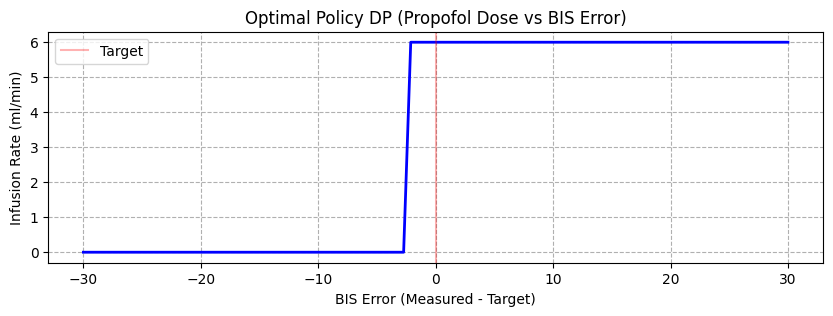


Evaluating policy for 10 episodes...


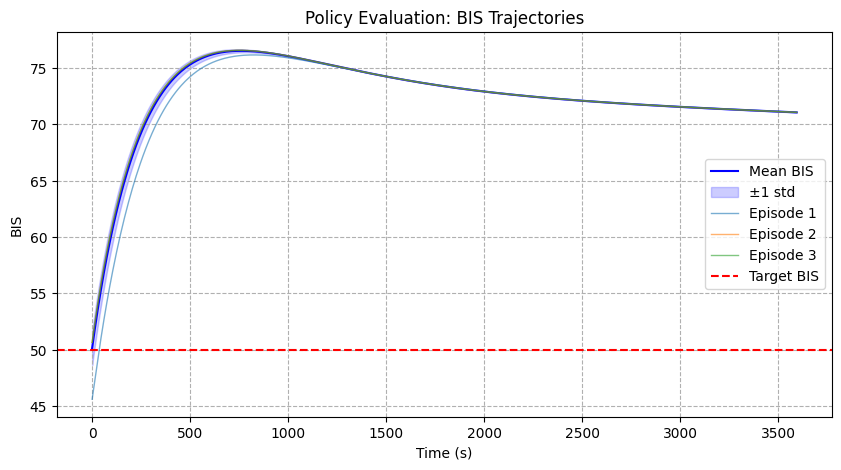

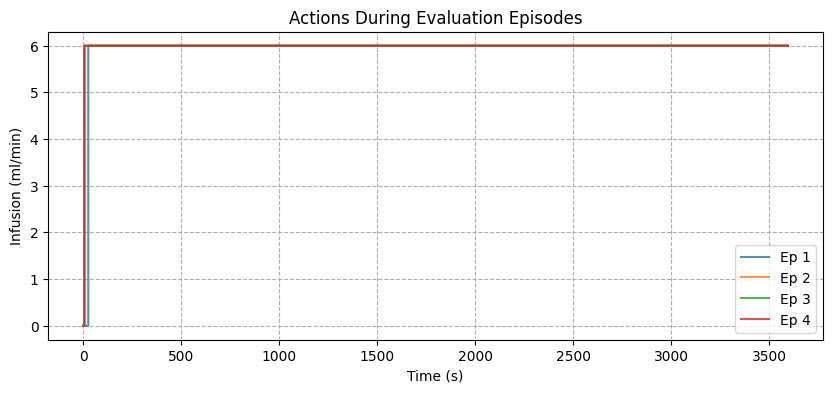

✓ Training complete!


In [ ]:
# ============================================================================
# VISUALIZATION: POLICY AND EVALUATION TRACES
# ============================================================================

errors = np.linspace(-30, 30, 100)
chosen_doses = []
for e in errors:
    s = state_to_idx(get_fuzzy_features(e))
    chosen_doses.append(ACTIONS[policy[s]])

plt.figure(figsize=(10, 3))
plt.plot(errors, chosen_doses, color='blue', lw=2)
plt.title("Optimal Policy DP (Propofol Dose vs BIS Error)")
plt.xlabel("BIS Error (Measured - Target)")
plt.ylabel("Infusion Rate (ml/min)")
plt.grid(True, linestyle='--')
plt.axvline(0, color='red', linestyle='-', alpha=0.3, label="Target")
plt.legend()
plt.show()

print("✓ Training complete!")

# EVALUATION ON POPULATION DATASET

In [36]:
# ============================================================================
# EVALUATION ON POPULATION DATASET
# ============================================================================

from utils.eval_metrics import (
    calculate_bis_metrics, get_age_group, create_results_dataframe,
    create_summary_by_age_group, save_evaluation_results
)

# ============================================================================
# DATA LOADING AND PREPROCESSING
# ============================================================================

def load_data(path):
    """Load patient data from CSV."""
    return pd.read_csv(path)

def preprocess_data(df):
    """Parse age categories to numeric values."""
    df = df.copy()
    def parse_age(x):
        try:
            parts = str(x).strip().split(" ")
            if len(parts) < 2:
                return 50
            low = int(parts[1])
            if len(parts) > 3:
                high = 100 if parts[3] == 'older' else int(parts[3])
                return int(random.randrange(low, high))
            return int(low)
        except Exception:
            return 50
    
    if "AgeCategory" in df.columns:
        df.loc[:, "AgeCategory"] = df["AgeCategory"].apply(parse_age)
    return df

def schnider_model(age, weight, height, sex):
    """Compute personalized Schnider PK/PD parameters."""
    sex = str(sex).lower()
    if sex == "male":
        lbm = 1.10 * weight - 128 * (weight ** 2) / (height ** 2)
    else:
        lbm = 1.07 * weight - 148 * (weight ** 2) / (height ** 2)

    V1_s = 4.27
    V2_s = 18.9 - 0.391 * (age - 53)
    V3_s = 238.0

    k10_s = 0.443 + 0.0107 * (weight - 77) - 0.0159 * (lbm - 59) + 0.0062 * (height - 177)
    k12_s = 0.302 - 0.0056 * (age - 53)
    k13_s = 0.196
    k21_s = (1.29 - 0.024 * (age - 53)) / V2_s
    k31_s = 0.0035
    ke0_s = 0.456

    A = np.array([
        [-(k10_s + k12_s + k13_s), k21_s, k31_s, 0],
        [k12_s, -k21_s, 0, 0],
        [k13_s, 0, -k31_s, 0],
        [ke0_s, 0, 0, -ke0_s]
    ], dtype=float)
    B = np.array([[1 / V1_s], [0], [0], [0]], dtype=float)
    
    return {"A": A, "B": B}

def generate_schnider_dataset(df):
    """Generate Schnider parameters for all patients."""
    params_list = []
    for _, row in df.iterrows():
        params = schnider_model(
            age=row["AgeCategory"],
            weight=row["WeightInKilograms"],
            height=row["HeightInMeters"],
            sex=row["Sex"]
        )
        params_list.append(params)
    
    params_df = pd.DataFrame(params_list)
    return pd.concat([df.reset_index(drop=True), params_df], axis=1)

# ============================================================================
# EVALUATOR CLASS
# ============================================================================

class DPEvaluator:
    """Evaluate DP policy on patient population."""
    
    def __init__(self, policy, actions):
        self.policy = policy
        self.actions = actions
        self.target = TARGET_BIS
        self.bis0 = BIS_0
        self.bis_max = BIS_MAX
        self.ec50 = EC50
        self.hill = HILL
        self.bins_per_feat = BINS_PER_FEAT

    def _get_state_idx(self, error):
        """Map BIS error to state index."""
        error = np.clip(float(error), -50.0, 50.0) if np.isfinite(error) else 0.0
        features = get_fuzzy_features(error)
        return state_to_idx(features)

    def simulate(self, patient_row, duration_seconds):
        """Simulate policy on patient for specified duration."""
        duration_steps = int(duration_seconds / 5)
        
        A = np.asarray(patient_row['A'], dtype=float)
        B = np.asarray(patient_row['B'], dtype=float)
        x = np.zeros((4, 1), dtype=float)
        
        bis_log = []
        
        for _ in range(duration_steps):
            ce = np.clip(float(x[3, 0]), 0.0, 10.0)
            
            if not np.isfinite(ce):
                ce = 0.0
                x = np.zeros((4, 1), dtype=float)
            
            ce_h = np.power(ce, self.hill)
            ec50_h = np.power(self.ec50, self.hill)
            
            if ec50_h + ce_h > 0:
                bis_ideal = self.bis0 - self.bis_max * (ce_h / (ec50_h + ce_h))
            else:
                bis_ideal = self.bis0
            
            bis_ideal = np.clip(float(bis_ideal), 0, 100) if np.isfinite(bis_ideal) else self.bis0
            measured_bis = np.clip(bis_ideal + np.random.normal(0, 3), 0, 100)
            
            error = np.clip(float(measured_bis - self.target), -50.0, 50.0)
            s_idx = self._get_state_idx(error)
            a_idx = int(self.policy[s_idx])
            u = float(self.actions[a_idx])
            
            x_dot = A @ x + B * u
            x = x + x_dot * EVAL_TIME_STEP
            x = np.clip(x, -10.0, 10.0)
            
            bis_log.append(float(measured_bis))
        
        return np.array(bis_log)

# ============================================================================
# EVALUATION EXECUTION
# ============================================================================

print("\n" + "=" * 70)
print("EVALUATION ON POPULATION DATASET")
print("=" * 70)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Load and preprocess data
print(f"\n1. Loading patient data from {DATA_PATH}...")
df = load_data(DATA_PATH)
df = preprocess_data(df)
print(f"   ✓ Loaded {len(df)} patients")

# Sample patients
print(f"\n2. Sampling {EVAL_SAMPLE_SIZE} patients...")
sample_df = df.sample(n=min(EVAL_SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED)
print(f"   ✓ Sampled {len(sample_df)} patients")

# Generate Schnider parameters
print(f"\n3. Generating Schnider PK/PD parameters...")
eval_df = generate_schnider_dataset(sample_df)
print(f"   ✓ Generated parameters for {len(eval_df)} patients")

# Load trained DP policy
print(f"\n4. Loading trained DP agent...")
dp_data = np.load(DP_PATH)
policy_eval = dp_data["policy"]
actions_eval = dp_data["actions"]
print(f"   ✓ Loaded policy: shape {policy_eval.shape}")

# Run evaluation
evaluator = DPEvaluator(policy_eval, actions_eval)

print(f"\n5. Evaluating policy at {len(EVAL_EPISODE_LENGTHS)} episode lengths...")
patient_results = []

for idx, (_, patient) in enumerate(eval_df.iterrows()):
    if (idx + 1) % 50 == 0:
        print(f"   Processing patient {idx + 1}/{len(eval_df)}...")
    
    patient_id = patient['PatientID']
    age = patient['AgeCategory']
    age_group = get_age_group(age, AGE_GROUPS)
    
    results = {}
    for ep_len in EVAL_EPISODE_LENGTHS:
        bis_traj = evaluator.simulate(patient, ep_len)
        metrics = calculate_bis_metrics(bis_traj, TARGET_BIS)
        results[ep_len] = metrics
    
    patient_results.append({
        'patient_id': patient_id,
        'age': age,
        'age_group': age_group,
        'results': results
    })

# Create DataFrames
results_df = create_results_dataframe(patient_results, EVAL_EPISODE_LENGTHS)
summary_df = create_summary_by_age_group(results_df, EVAL_EPISODE_LENGTHS, AGE_GROUPS)

# Save results
print(f"\n6. Saving evaluation results...")
save_evaluation_results(
    results_df, 
    summary_df, 
    "dp_agent_error",
    str(METRICS_DIR)
)

print(f"\n" + "=" * 70)
print(f"Evaluation complete!")
print(f"  - Results: {len(results_df)} patients")
print(f"  - Age groups: {results_df['AgeGroup'].nunique()}")
print(f"  - Episode lengths: {len(EVAL_EPISODE_LENGTHS)}")
print(f"=" * 70)


EVALUATION ON POPULATION DATASET

1. Loading patient data from data\Patients Data.csv...
   ✓ Loaded 237630 patients

2. Sampling 500 patients...
   ✓ Sampled 500 patients

3. Generating Schnider PK/PD parameters...
   ✓ Generated parameters for 500 patients

4. Loading trained DP agent...
   ✓ Loaded policy: shape (1000,)

5. Evaluating policy at 4 episode lengths...
   Processing patient 50/500...
   Processing patient 100/500...
   Processing patient 150/500...
   Processing patient 200/500...
   Processing patient 250/500...
   Processing patient 300/500...
   Processing patient 350/500...
   Processing patient 400/500...
   Processing patient 450/500...
   Processing patient 500/500...

6. Saving evaluation results...
Saved results to metrics\dp_agent_error_results.csv
Saved summary to metrics\dp_agent_error_summary.csv

Evaluation complete!
  - Results: 500 patients
  - Age groups: 6
  - Episode lengths: 4


# QUICK EVALUATION (Smaller Sample)

In [37]:
# Quick evaluation with reduced sample (optional - for testing)
# Change EVAL_SAMPLE_SIZE above to a smaller value (e.g., 50) before running this cell

print("Running quick evaluation with current sample size...")
print("(To use a smaller sample, modify EVAL_SAMPLE_SIZE at the top and re-run the evaluation cell above)")

Running quick evaluation with current sample size...
(To use a smaller sample, modify EVAL_SAMPLE_SIZE at the top and re-run the evaluation cell above)
